# **Model-4: LFCC-LCNN using Cosface Loss and FreqAugment**

## **Imports**


In [1]:
import os
import sys
import glob
import random
import librosa
import numpy as np
from tqdm import tqdm
from joblib import Parallel, delayed
import torchaudio
import torchaudio.transforms as T
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary
import scipy
from scipy.optimize import brentq 
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import Normalize
from collections import defaultdict
from sklearn.metrics import confusion_matrix, f1_score, roc_curve, auc


## **Main Configuration**

In [2]:
# --- Main Configuration ---
DATASET_BASE_DIR = '/kaggle/input/asvspoof-2019-la/ASVspoof2019_LA_wav'
PRECOMPUTED_BASE_DIR = '/kaggle/working/precomputed_lfcc'
TRAIN_OUTPUT_DIR = os.path.join(PRECOMPUTED_BASE_DIR, 'train')
DEV_OUTPUT_DIR = os.path.join(PRECOMPUTED_BASE_DIR, 'dev')
EVAL_OUTPUT_DIR = os.path.join(PRECOMPUTED_BASE_DIR, 'eval')

MODEL_CHECKPOINT = '/kaggle/working/LFCC_LCNN_cosface_freqaug.pth'

# Create output directories
os.makedirs(TRAIN_OUTPUT_DIR, exist_ok=True)
os.makedirs(DEV_OUTPUT_DIR, exist_ok=True)
os.makedirs(EVAL_OUTPUT_DIR, exist_ok=True)

# --- Paths ---
TRAIN_PROTOCOL = os.path.join(DATASET_BASE_DIR, 'ASVspoof2019_LA_cm_protocols', 'ASVspoof2019.LA.cm.train.trn.txt')
DEV_PROTOCOL = os.path.join(DATASET_BASE_DIR, 'ASVspoof2019_LA_cm_protocols', 'ASVspoof2019.LA.cm.dev.trl.txt')
EVAL_PROTOCOL = os.path.join(DATASET_BASE_DIR, 'ASVspoof2019_LA_cm_protocols', 'ASVspoof2019.LA.cm.eval.trl.txt')

TRAIN_AUDIO_DIR = os.path.join(DATASET_BASE_DIR, 'ASVspoof2019_LA_train', 'flac')
DEV_AUDIO_DIR = os.path.join(DATASET_BASE_DIR, 'ASVspoof2019_LA_dev', 'flac')
EVAL_AUDIO_DIR = os.path.join(DATASET_BASE_DIR, 'ASVspoof2019_LA_eval', 'flac')

# --- Feature Parameters ---
SAMPLE_RATE = 16000
N_LFCC = 20 # Number of static coefficients
N_FEATURES = N_LFCC * 3 # 20 static + 20 delta + 20 delta-delta = 60
MAX_FRAMES = 600
WIN_LENGTH = int(0.020 * SAMPLE_RATE) # 320 samples
HOP_LENGTH = int(0.010 * SAMPLE_RATE) # 160 samples

# ---Other Parameters ---
NUM_CLASSES=2

# **LFCC Feature Extraction**

In [4]:
def extract_lfcc(audio_path, target_sr=SAMPLE_RATE):
    """
    Extracts 60-dimensional LFCC features using the configuration from Lavrentyeva et al. (2019)
    using torchaudio.

    Args:
        audio_path (str): Path to the audio file.
        target_sr (int): Target sample rate. The ASVspoof 2019 dataset is 16 kHz.

    Returns:
        torch.Tensor: LFCC features with shape (1, 60, num_frames).
    """
    try:
        waveform, sample_rate = torchaudio.load(audio_path)
    except Exception as e:
        print(f"Error loading {audio_path}: {e}")
        return None
        
    if sample_rate != target_sr:
        resampler = torchaudio.transforms.Resample(orig_freq=sample_rate, new_freq=target_sr)
        waveform = resampler(waveform)
    
    # Convert to single channel and apply pre-emphasis
    waveform = waveform.mean(dim=0, keepdim=True)
    preemphasis_filter = T.Preemphasis(coeff=0.97)
    waveform = preemphasis_filter(waveform)

    # Compute LFCCs
    lfcc_transform = T.LFCC(
        sample_rate=target_sr,
        n_lfcc=N_LFCC,
        speckwargs={
            'n_fft': 512,
            'win_length': WIN_LENGTH,
            'hop_length': HOP_LENGTH,
            'power': 2.0
        }
    )
    lfccs = lfcc_transform(waveform)

    # Compute delta and delta-delta coefficients
    delta = T.ComputeDeltas(win_length=3)(lfccs)
    delta2 = T.ComputeDeltas(win_length=3)(delta)

    # Concatenate static, delta, and delta-delta
    # concatenate delta coefficients to the LFCCs --> dim = 1
    full_lfccs = torch.cat((lfccs, delta, delta2), dim=1) 
    
    return full_lfccs

def process_and_save(file_path, audio_id, label, output_dir):
    """
    Loads audio, extracts LFCC features, and saves them to a .pt file.
    """
    try:
        # Extract features using the dedicated function
        lfcc_features = extract_lfcc(file_path)
        if lfcc_features is None:
            return None, None

        # Pad or truncate to MAX_FRAMES = 600
        num_frames = lfcc_features.shape[2] # Shape is (1, 60, 600)
        if num_frames > MAX_FRAMES:
            start_frame = (num_frames - MAX_FRAMES) // 2
            lfcc_features = lfcc_features[:, :, start_frame : start_frame + MAX_FRAMES]
        elif num_frames < MAX_FRAMES:
            padding = MAX_FRAMES - num_frames
            padding_left = padding // 2
            padding_right = padding - padding_left
            lfcc_features = torch.nn.functional.pad(lfcc_features,
                                                    (padding_left, padding_right),
                                                    "constant", 0
                                                   )

        # Input shape from extract_lfcc is (1, 60, 600)
        # Transpose to (frames, features, channels)==(600, 60, 1) and unsqueeze channel dim
        lfcc_features = lfcc_features.squeeze(0).T.unsqueeze(-1)
        
        # Save the tensor and label
        file_info = {
            'features': lfcc_features.to(torch.float16),
            'label': torch.tensor(label, dtype=torch.long)
        }
        
        out_path = os.path.join(output_dir, audio_id + '.pt')
        torch.save(file_info, out_path)
        
        return audio_id, label
    except Exception as e:
        print(f"Error with {file_path}: {e}")
        return None, None

def parse_protocol(protocol_file, audio_dir):
    """
    Parses protocol file and returns a list of tuples (file_path, audio_id, label).
    I had to first convert the entire dataset to .wav
    """
    file_info = []
    if not os.path.exists(protocol_file):
        print(f"Warning: Protocol file not found: {protocol_file}")
        return file_info
    
    with open(protocol_file, 'r') as f:
        for line in f:
            parts = line.strip().split(' ')
            if len(parts) >= 5:
                audio_file_id = parts[1]
                file_path = os.path.join(audio_dir, audio_file_id + '.wav')
                if os.path.exists(file_path):
                    label = 1 if parts[4].lower() == 'spoof' else 0
                    file_info.append((file_path, audio_file_id, label))
                else:
                    print(f"Warning: Audio file not found: {file_path}")
            
    return file_info

def batch_extract_and_save(protocol_path, audio_dir, output_dir):
    """
    Main function to parallel process and save the full dataset split.
    """
    print(f"Starting processing for {output_dir}...")
    file_info = parse_protocol(protocol_path, audio_dir)
    
    results = Parallel(n_jobs=-1)(
        delayed(process_and_save)(path, audio_id, label, output_dir)
        for path, audio_id, label in tqdm(file_info, desc=f"Saving to {output_dir}")
    )
    
    label_map = {audio_id: label for audio_id, label in results if audio_id is not None}
    label_path = os.path.join(output_dir, 'labels.pt')
    torch.save(label_map, label_path)
    
    print(f"Finished. Saved {len(label_map)} features and labels to: {output_dir}")


# Precomputation of LFCC features, saved to working directory as .pt files

if not os.path.exists(TRAIN_OUTPUT_DIR) or not os.listdir(TRAIN_OUTPUT_DIR):
    print("Precomputing training features...")
    batch_extract_and_save(TRAIN_PROTOCOL, TRAIN_AUDIO_DIR, TRAIN_OUTPUT_DIR)
else:
    print("Training features already precomputed.")

if not os.path.exists(DEV_OUTPUT_DIR) or not os.listdir(DEV_OUTPUT_DIR):
    print("Precomputing development features...")
    batch_extract_and_save(DEV_PROTOCOL, DEV_AUDIO_DIR, DEV_OUTPUT_DIR)
else:
    print("Development features already precomputed.")

if not os.path.exists(EVAL_OUTPUT_DIR) or not os.listdir(EVAL_OUTPUT_DIR):
    print("Precomputing evaluation features...")
    batch_extract_and_save(EVAL_PROTOCOL, EVAL_AUDIO_DIR, EVAL_OUTPUT_DIR)
else:
    print("Evaluation features already precomputed.")

Training features already precomputed.
Development features already precomputed.
Evaluation features already precomputed.


# **Model Definition**

## **Max-Feature-Map Activation and LCNN Model**

In [5]:
# Max Feature Map
class MaxFeatureMap(nn.Module):
    """
    Max-Feature-Map (MFM) activation layer for Conv layers.
    Splits along the channel dimension.
    """
    def __init__(self):
        super(MaxFeatureMap, self).__init__()
        
    def forward(self, x):
        # Splits the input tensor along the channel dimension (dim=1)
        x1, x2 = torch.split(x, x.size(1) // 2, dim=1)
        return torch.max(x1, x2)



# LCNN
class LCNN(nn.Module):
    def __init__(self, sample_input_shape):
        super(LCNN, self).__init__()
        
        self.mfm = MaxFeatureMap()

        # --- LCNN Body (Convolutional Layers) ---
        self.conv1 = nn.Conv2d(1, 64, kernel_size=(5, 5), padding='same')
        self.mp1 = nn.MaxPool2d(kernel_size=(2, 2))
        self.conv4 = nn.Conv2d(32, 64, kernel_size=(1, 1), padding='same')
        self.bn1 = nn.BatchNorm2d(32)
        self.conv7 = nn.Conv2d(32, 96, kernel_size=(3, 3), padding='same')
        self.mp2 = nn.MaxPool2d(kernel_size=(2, 2))
        self.bn2 = nn.BatchNorm2d(48)
        self.conv11 = nn.Conv2d(48, 96, kernel_size=(1, 1), padding='same')
        self.bn3 = nn.BatchNorm2d(48)
        self.conv14 = nn.Conv2d(48, 128, kernel_size=(3, 3), padding='same')
        self.mp3 = nn.MaxPool2d(kernel_size=(2, 2))
        self.conv17 = nn.Conv2d(64, 128, kernel_size=(1, 1), padding='same')
        self.bn4 = nn.BatchNorm2d(64)
        self.conv20 = nn.Conv2d(64, 64, kernel_size=(3, 3), padding='same')
        self.bn5 = nn.BatchNorm2d(32)
        self.conv23 = nn.Conv2d(32, 64, kernel_size=(1, 1), padding='same')
        self.bn6 = nn.BatchNorm2d(32)
        self.conv26 = nn.Conv2d(32, 64, kernel_size=(3, 3), padding='same')
        self.mp4 = nn.MaxPool2d(kernel_size=(2, 2))

         # --- Dynamic Calculation of Input Size for Linear Layer ---
        dummy_input = torch.randn(1, 1, *sample_input_shape[:2])
        conv_output = self._forward_conv(dummy_input)
        flattened_size = conv_output.reshape(1, -1).size(1)
        print(f"Dynamically calculated flattened size based on real data: {flattened_size}")

        # --- Fully Connected (Linear) Layers ---
        self.fc29 = nn.Linear(flattened_size, 160)
        self.bn7 = nn.BatchNorm1d(80)
        self.dropout = nn.Dropout(p=0.75)

    def _forward_conv(self, x):
        """A helper function to pass data through the conv layers."""
        # This logic is identical to the forward pass, used for shape calculation
        x = self.mfm(self.conv1(x))
        x = self.mp1(x)
        x = self.mfm(self.conv4(x))
        x = self.bn1(x)
        x = self.mfm(self.conv7(x))
        x = self.mp2(x)
        x = self.mfm(self.conv11(x))
        x = self.bn3(x)
        x = self.mfm(self.conv14(x))
        x = self.mp3(x)
        x = self.mfm(self.conv17(x))
        x = self.bn4(x)
        x = self.mfm(self.conv20(x))
        x = self.bn5(x)
        x = self.mfm(self.conv23(x))
        x = self.bn6(x)
        x = self.mfm(self.conv26(x))
        x = self.mp4(x)
        return x

    def forward(self, x):
        # Pass through all the convolutional layers
        x = self._forward_conv(x)
        
        # Flatten the tensor before the linear layer
        x = x.reshape(x.size(0), -1)

        # Pass through the first linear layer
        x = self.fc29(x)
        
        # --- MFM for Linear Layer ---
        # Output of fc29 is (batch, 160). We reshape to (batch, 2, 80)
        x = x.view(x.size(0), 2, -1) 
        # Then take the max along the new dimension (dim=1)
        x = torch.max(x, dim=1)[0] # Shape becomes (batch, 80)

        x = self.bn7(x)
        embeddings = self.dropout(x)
        return embeddings



## **CosFace Layer (Large Margin Cosine Loss)**

In [6]:
class CosFace(nn.Module):
    """
    Cosface layer with a trainable weight matrix.
    
    CosFace: Large Margin Cosine Loss for Deep Face Recognition (CVPR '18)
    Hao Wang, Yitong Wang, Zheng Zhou, Xing Ji, Dihong Gong, Jingchao Zhou, Zhifeng Li, Wei Liu
    https://arxiv.org/abs/1801.09414
    
    Sourced and adapted from: https://github.com/phillity/metric_learning/blob/master/losses/angular_margin_loss/cosface_loss.py
    """
    def __init__(self, in_features, num_classes, scale=10.0, margin=0.30):
        super(CosFace, self).__init__()
        self.in_features = in_features
        self.num_classes = num_classes
        self.scale = scale
        self.margin = margin

        self.W = nn.Parameter(torch.Tensor(in_features, num_classes))
        nn.init.xavier_uniform_(self.W)  # Using xavier uniform initializer

    def forward(self, embeddings, labels=None):
        # Normalise weights and embeddings
        W_norm = F.normalize(self.W, p=2, dim=0)
        embeddings_norm = F.normalize(embeddings, p=2, dim=1)

        # Calculate cosine similarity (logits for inference)
        cosine_logits = embeddings_norm.mm(W_norm)
        
        # If no labels are provided (i.e., during evaluation), return the raw scaled logits
        # This is for inference only
        if labels is None:
            return cosine_logits * self.scale

        # --- Training Path (when labels are provided) ---
        # Apply margin to the target class logits
        # Create a tensor for the labels
        one_hot = torch.zeros_like(cosine_logits)
        one_hot.scatter_(1, labels.view(-1, 1).long(), 1)

        # Apply the margin
        target_logits = cosine_logits - self.margin
        
        # Replace the original logits for the target class with the margined logits
        output = (cosine_logits * (1 - one_hot)) + (target_logits * one_hot)

        # Apply the scale
        output *= self.scale
        
        return output

# **Model Training**

In [7]:
class LFCCDataset(Dataset):
    def __init__(self, data_dir):
        # Store the directory where .pt files are saved
        self.data_dir = data_dir
        # Create a list of all .pt file paths in the directory
        # The glob.glob function finds all files matching the pattern '*.pt'
        self.file_list = glob.glob(os.path.join(data_dir, '*.pt'))
        # Exclude the labels.pt file which is not a feature file
        self.file_list = [f for f in self.file_list if not os.path.basename(f).startswith('labels')]

    def __len__(self):
        # This function returns the total number of samples in the dataset
        return len(self.file_list)

    def __getitem__(self, idx):
        file_path = self.file_list[idx]
        # Load the dictionary saved with features and labels
        data = torch.load(file_path)
        # Extract the features tensor
        features = data['features'].float() # Shape: (600, 60, 1)
        # Extract the label tensor
        label = data['label']
        # Return both the features and the label as a tuple
        return features, label



#Check GPU Copmatibility
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


# --- Data Loading ---
print("Loading datasets...")
train_dataset = LFCCDataset(TRAIN_OUTPUT_DIR)
dev_dataset = LFCCDataset(DEV_OUTPUT_DIR)
eval_dataset = LFCCDataset(EVAL_OUTPUT_DIR)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=os.cpu_count())
dev_loader = DataLoader(dev_dataset, batch_size=32, shuffle=False, num_workers=os.cpu_count())
eval_loader = DataLoader(eval_dataset, batch_size=32, shuffle=False, num_workers=os.cpu_count())



# --- Model, Loss, and Optimiser ---
print("Creating LCNN model with Cosface...")
# Get the shape of a single sample from the dataset
sample_features, _ = train_dataset[0]# The features have shape [600, 60, 1], CNN input just needs height and width
input_shape = sample_features.shape
print(f"Sample input shape from dataset: {input_shape}")

# Define model 
lcnn_model = LCNN(input_shape).to(device)
cosface_layer = CosFace(in_features=80, num_classes=NUM_CLASSES).to(device)

Using device: cuda
Loading datasets...
Creating LCNN model with Cosface...
Sample input shape from dataset: torch.Size([600, 60, 1])
Dynamically calculated flattened size based on real data: 3552


In [8]:
# --- Loss and Optimiser ---
optimizer = optim.Adam(
    list(lcnn_model.parameters()) + list(cosface_layer.parameters()),
    lr=0.0001
)
criterion = nn.CrossEntropyLoss()

# --- Training Loop ---
num_epochs = 50
best_val_loss = float('inf')
patience_counter = 0
patience = 15
train_accuracy_history = []
train_loss_history =[]
val_loss_history = []
val_accuracy_history = []
# --- Frequency Augmentation Transform ---
freq_mask_transform = T.FrequencyMasking(freq_mask_param=3, iid_masks=False)

print("Starting training...")
for epoch in range(num_epochs):
    lcnn_model.train()
    cosface_layer.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0
    for features, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} Training"):
        features, labels = features.to(device), labels.to(device)

        # Apply Frequency Masking on the batch
        # 1. Permute for torchaudio transform: (32, 600, 60, 1) -> (32, 1, 60, 600)
        features_permuted_for_torchaudio = features.permute(0, 3, 2, 1)
        features_masked = freq_mask_transform(features_permuted_for_torchaudio)

        # 2. Permute back for the LCNN model: (32, 1, 60, 600) -> (32, 1, 600, 60)
        features_for_model = features_masked.permute(0, 1, 3, 2)
        
        optimizer.zero_grad()
        
        # Forward pass: get embeddings from the LCNN using the augmented features
        embeddings = lcnn_model(features_for_model)
        
        # Get modified logits from the Cosface layer
        logits = cosface_layer(embeddings, labels)
        
        # Calculate the loss
        loss = criterion(logits, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * features.size(0)
        # Calculate training accuracy for the batch
        # To get predictions, fetch the standard logits without the angular margin
        with torch.no_grad():
            logits_for_acc = cosface_layer(embeddings) 
            _, predicted = torch.max(logits_for_acc.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
    # Validation loop
    lcnn_model.eval()
    cosface_layer.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for features, labels in tqdm(dev_loader, desc=f"Epoch {epoch+1}/{num_epochs} Validation"):
            features, labels = features.to(device), labels.to(device)
            # Permute for the LCNN model in validation, no augmentation
            features_for_model = features.permute(0, 3, 1, 2)

            embeddings = lcnn_model(features_for_model)
            logits = cosface_layer(embeddings) 
            
            loss = criterion(logits, labels)
            val_loss += loss.item() * features.size(0)
            
            _, predicted = torch.max(logits.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    # Calculate and print core metrics
    epoch_loss = running_loss / len(train_dataset)
    epoch_train_accuracy = 100 * train_correct / train_total
    val_loss /= len(dev_dataset)
    val_accuracy = 100 * val_correct / val_total

    train_loss_history.append(epoch_loss)
    train_accuracy_history.append(epoch_train_accuracy)
    val_loss_history.append(val_loss)
    val_accuracy_history.append(val_accuracy)
    
    print(f'Epoch {epoch+1}: Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_train_accuracy:.2f}%, '
          f'Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.2f}%')

    # Early stopping and model saving
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save({
            'lcnn_state_dict': lcnn_model.state_dict(),
            'cosface_state_dict': cosface_layer.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_loss': best_val_loss,
        }, MODEL_CHECKPOINT)
        print(f"Model saved to 'LFCC_LCNN_cosface_freqaug3.pth' with new best validation loss: {best_val_loss:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break
print("Training finished.")

Starting training...


Epoch 1/50 Validation: 100%|██████████| 777/777 [00:22<00:00, 34.70it/s]


Epoch 1: Train Loss: 1.6288, Train Acc: 79.40%, Val Loss: 0.6135, Val Acc: 89.70%
Model saved to 'LFCC_LCNN_cosface_freqaug3.pth' with new best validation loss: 0.6135


Epoch 2/50 Validation: 100%|██████████| 777/777 [00:22<00:00, 34.84it/s]


Epoch 2: Train Loss: 0.5268, Train Acc: 94.07%, Val Loss: 0.0518, Val Acc: 99.34%
Model saved to 'LFCC_LCNN_cosface_freqaug3.pth' with new best validation loss: 0.0518


...

Epoch 48: Train Loss: 0.0091, Train Acc: 99.95%, Val Loss: 0.0013, Val Acc: 99.99%
Model saved to 'LFCC_LCNN_cosface_freqaug3.pth' with new best validation loss: 0.0013


Epoch 49/50 Validation: 100%|██████████| 777/777 [00:22<00:00, 34.98it/s]


Epoch 49: Train Loss: 0.0089, Train Acc: 99.95%, Val Loss: 0.0013, Val Acc: 99.99%
Model saved to 'LFCC_LCNN_cosface_freqaug3.pth' with new best validation loss: 0.0013


Epoch 50/50 Validation: 100%|██████████| 777/777 [00:22<00:00, 35.03it/s]

Epoch 50: Train Loss: 0.0115, Train Acc: 99.92%, Val Loss: 0.0009, Val Acc: 99.99%
Model saved to 'LFCC_LCNN_cosface_freqaug3.pth' with new best validation loss: 0.0009
Training finished.


## **Training and Validation Plots**

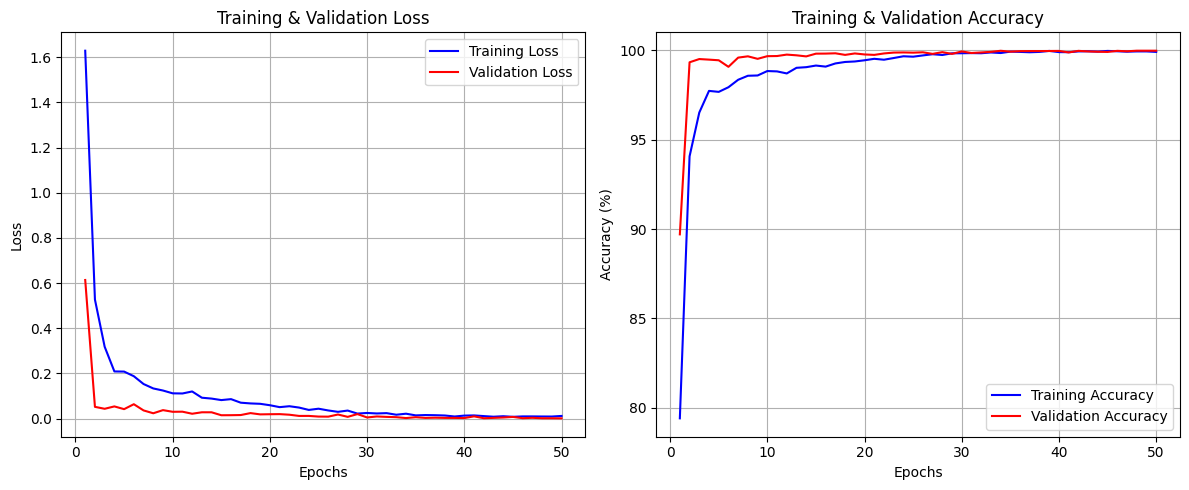

In [9]:
# Plotting the loss and accuracy curves
epochs = range(1, len(train_loss_history) + 1)

plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss_history, 'b', label='Training Loss')
plt.plot(epochs, val_loss_history, 'r', label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracy_history, 'b', label='Training Accuracy') 
plt.plot(epochs, val_accuracy_history, 'r', label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# **Evaluating Model-4 on Development and Evaluation Sets**

In [10]:
def evaluate_model(model, cosface, data_loader, device, dataset_name="Dataset"):
    """
    Evaluates the model on a given dataset and prints performance metrics.
    
    Args:
        model (nn.Module): The LCNN model.
        cosface (nn.Module): The CosFace layer.
        data_loader (DataLoader): DataLoader for the dataset to evaluate.
        device (torch.device): The device to run evaluation on (e.g., 'cuda').
        dataset_name (str): A name for the dataset for clear printouts.
    """
    model.eval()
    cosface.eval()
    
    labels_list = []
    scores_list = []  
    preds_list = []
    with torch.no_grad():
        for features, labels in tqdm(data_loader, desc=f"Evaluating on {dataset_name}"):
            features, labels = features.to(device), labels.to(device)
            features_for_model = features.permute(0, 3, 1, 2)
            embeddings = model(features_for_model)
            logits = cosface(embeddings)

            _, predicted = torch.max(logits.data, 1)
            softmax_scores = F.softmax(logits, dim=1)
            
            labels_list.extend(labels.cpu().numpy())
            scores_list.extend(softmax_scores[:, 1].cpu().numpy())
            preds_list.extend(predicted.cpu().numpy())

    # --- Calculate Metrics ---
    cm = confusion_matrix(labels_list, preds_list)
    f1 = f1_score(labels_list, preds_list)
    
    # EER is calculated from the raw scores
    fpr, tpr, _ = roc_curve(labels_list, scores_list, pos_label=1)
    fnr = 1 - tpr
    eer_index = np.nanargmin(np.abs(fnr - fpr))
    eer = fpr[eer_index]

    print(f"\n--- Model Performance on {dataset_name} ---")
    print(f"Confusion Matrix:\n{cm}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Equal Error Rate (EER): {eer * 100:.2f}%")
    print("-" * 50)

    
    return {
        'fpr': fpr,
        'tpr': tpr,
        'eer': eer,
        'f1': f1,
        'cm': cm
    }

## **Per-Attack EER Function**

In [11]:
def calculate_eer(labels, scores):
    if len(np.unique(labels)) < 2:
        return np.nan
    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    # The EER is the point where FPR is closest to FNR (1 - TPR)
    eer_index = np.argmin(np.abs(fpr - (1 - tpr)))
    eer = fpr[eer_index]
    return eer * 100


def evaluate_per_attack(lcnn_model, cosface_layer, protocol_path, output_dir, device, dataset_name="Dataset"):
    """
    Performs per-attack EER evaluation on a specified dataset.

    Args:
        lcnn_model (nn.Module): The LCNN feature extraction model.
        cosface_layer (nn.Module): The CosFace classification layer.
        protocol_path (str): Path to the ASVspoof protocol file (e.g., DEV_PROTOCOL).
        output_dir (str): Path to the directory containing pre-extracted feature tensors (e.g., DEV_OUTPUT_DIR).
        device (torch.device): The device (e.g., 'cuda' or 'cpu') to run the model on.
        dataset_name (str): A name for the dataset for clear printouts (e.g., 'DEVELOPMENT' or 'EVALUATION').

    Returns:
        dict: A dictionary containing attack_id and its corresponding EER (%).
    """
    print(f"\n--- Starting Per-attack Evaluation on {dataset_name} Set ---")
    
    # Set models to evaluation mode
    lcnn_model.eval()
    cosface_layer.eval()

    # --- Step 1: Load Protocol ---
    protocol_entries = []
    try:
        with open(protocol_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                utt_id = parts[1]
                attack_id = parts[3] if parts[3] != '-' else 'bonafide'
                label = 1 if parts[-1] == 'spoof' else 0
                protocol_entries.append((utt_id, attack_id, label))
    except FileNotFoundError:
        print(f"Error: Protocol file not found at {protocol_path}. Skipping evaluation for {dataset_name}.")
        return {}

    # Separate results
    bonafide_scores = []
    bonafide_labels = []
    attack_results = defaultdict(lambda: {"scores": [], "labels": []})

    # --- Step 2: Process Data and Get Scores ---
    print(f"Starting {dataset_name} set per-attack score collection...")
    for utt_id, attack_id, label in tqdm(protocol_entries, desc=f"{dataset_name} Per-attack Evaluation"):
        tensor_path = os.path.join(output_dir, utt_id + '.pt')
        if not os.path.exists(tensor_path):
            continue

        loaded_data = torch.load(tensor_path)
        features = loaded_data['features']

        if features.ndim == 3:
            features_for_model = features.unsqueeze(0).permute(0, 3, 1, 2)
        else:
            continue
        
        features_for_model = features_for_model.to(device).to(torch.float32)

        with torch.no_grad():
            embeddings = lcnn_model(features_for_model)
            logits = cosface_layer(embeddings)
            softmax_scores = F.softmax(logits, dim=1)
            # Score for the positive class (spoof/attack)
            score = softmax_scores[:, 1].item()

        if attack_id == 'bonafide':
            bonafide_scores.append(score)
            bonafide_labels.append(label)
        else:
            attack_results[attack_id]["scores"].append(score)
            attack_results[attack_id]["labels"].append(label)

    # --- Step 3: Compute Per-Attack EER ---
    final_eers = {}
    print(f"\n--- Per-attack Performance on {dataset_name} Set ---")
    
    # Check if there are bonafide samples to use as non-spoof class
    if not bonafide_scores:
         print("Warning: No bonafide samples found in protocol. Cannot compute per-attack EER.")
         return {}
         
    for attack_id, data in attack_results.items():
        # Combine the current attack's data with the bonafide data
        all_scores = bonafide_scores + data["scores"]
        all_labels = bonafide_labels + data["labels"]
        
        eer = calculate_eer(all_labels, all_scores)
        final_eers[attack_id] = eer
        
        print(f"{attack_id}: EER={eer:.2f}%")

    print(f"bonafide: EER=N/A (only bonafide samples found)")
    print("-" * 50)
    
    return final_eers

# **Plots**


## **ROC Curve plot**

In [ ]:
def plot_roc_curve(results, model_name="Model-4"):
    """
    Plots the ROC curve using the results from the evaluate_model function.
    
    Args:
        results (dict): The dictionary returned by evaluate_model.
        model_name (str): A name for the model/dataset for the plot title.
    """
    # Get the fpr and tpr from the results dictionary
    fpr = results['fpr']
    tpr = results['tpr']
    
    # Compute Area Under the Curve (AUC)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, color='darkred', lw=2, 
             label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve – {model_name}')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

## **Feature Visualisation Function**

In [13]:
def display_augmented_samples(feature_dir, num_samples=3, freq_mask_param=2):
    """
    Loads, augments, and displays LFCC features for random samples side-by-side,
    with an explicit black bar showing where the frequency mask was applied.

    Args:
        feature_dir (str): Path to the directory containing saved .pt feature files.
        num_samples (int): The number of random samples to display.
        freq_mask_param (int): The maximum width of the frequency mask.
    """
    all_files = [f for f in os.listdir(feature_dir) if f.endswith('.pt') and not f.startswith('labels')]
    if len(all_files) < num_samples:
        print(f"Warning: Only found {len(all_files)} files. Displaying all of them.")
        num_samples = len(all_files)
    if not all_files:
        print(f"No feature files found in {feature_dir}.")
        return

    selected_files = random.sample(all_files, num_samples)
    freq_mask_transform = T.FrequencyMasking(freq_mask_param=freq_mask_param, iid_masks=True)

    fig, axes = plt.subplots(num_samples, 2, figsize=(15, 5 * num_samples), squeeze=False)
    fig.suptitle('Original vs. Augmented LFCC Features', fontsize=18)

    for i, file_name in enumerate(selected_files):
        file_path = os.path.join(feature_dir, file_name)
        try:
            data = torch.load(file_path)
            features = data['features']
            label = data['label'].item()
            
            # Squeeze to (Time, LFCC_Coeffs)
            features_sq = features.squeeze(2)
            features_np = features_sq.numpy()
            
            # --- 1. Plot the Original Features ---
            ax_orig = axes[i, 0]
            im_orig = librosa.display.specshow(
                features_np.T, # Transpose for librosa plotting (60, 600)
                x_axis='frames',
                ax=ax_orig,
                cmap='magma'
            )
            title_color = 'red' if label == 1 else 'green'
            ax_orig.set_title(f'Sample {os.path.basename(file_path)} (Original) - {"Spoof" if label == 1 else "Bonafide"}', color=title_color)
            ax_orig.set_xlabel('Frames')
            ax_orig.set_ylabel('LFCC Coefficient')
            fig.colorbar(im_orig, ax=ax_orig, label='Amplitude')

            # --- 2. Augment and Plot the Masked Features ---
            ax_aug = axes[i, 1]
            
            # Prepare tensor for torchaudio, which needs (32, 1, 60, 600)
            features_for_transform = features_sq.T.unsqueeze(0).unsqueeze(0)
            
            # Create a clone to detect the mask later
            features_clone = features_for_transform.clone()

            # Apply frequency masking
            features_masked = freq_mask_transform(features_for_transform)
            augmented_features_np = features_masked.squeeze().numpy()

            # Normalise color mapping consistently
            vmin = np.min([features_np, augmented_features_np.T])
            vmax = np.max([features_np, augmented_features_np.T])

            
            # Plot the augmented features
            im_aug = librosa.display.specshow(
                augmented_features_np,
                x_axis='frames',
                ax=ax_aug,
                cmap='magma',
                vmin=vmin,
                vmax=vmax
            )
            
            # --- Overlay the black bar for the frequency mask ---
            # Detect where the tensor values were changed by the mask
            # compare the modified tensor to the original clone.
            diff_mask = (features_clone != features_masked).squeeze() # Shape (60, 600)
            
            # Check if any frequency bins were masked
            if diff_mask.sum() > 0:
                masked_freq_bins = torch.where(diff_mask.sum(dim=1) > 0)[0]
                if masked_freq_bins.numel() > 0:
                    start_freq_bin = masked_freq_bins.min().item()
                    mask_height = masked_freq_bins.numel()

                    # Overlay a black rectangle
                    rect = patches.Rectangle(
                        (0, start_freq_bin), # Bottom-left corner
                        augmented_features_np.shape[1], # Width in time frames
                        mask_height, # Height in freq bins
                        linewidth=0,
                        edgecolor='none',
                        facecolor='black',
                        alpha=0.6,
                        zorder=10 # Ensure rectangle is on top of the image
                    )
                    ax_aug.add_patch(rect)
                    ax_aug.set_title(f'Sample {os.path.basename(file_path)} (Augmented, Masked)', color='blue')
            else:
                ax_aug.set_title(f'Sample {os.path.basename(file_path)} (Augmented, No Mask)', color='blue')
            
            ax_aug.set_xlabel('Frames')
            ax_aug.set_ylabel('LFCC Coefficient')
            fig.colorbar(im_aug, ax=ax_aug, label='Amplitude')

        except Exception as e:
            print(f"Error processing or displaying features from {file_path}: {e}")
            axes[i, 0].set_title("Error")
            axes[i, 1].set_title("Error")

    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.show()


# **Main Execution**

Loaded best model from '/kaggle/working/LFCC_LCNN_cosface_freqaug.pth'.


Evaluating on Development Set: 100%|██████████| 777/777 [00:22<00:00, 35.17it/s]



--- Model Performance on Development Set ---
Confusion Matrix:
[[ 2545     3]
 [    0 22296]]
F1 Score: 0.9999
Equal Error Rate (EER): 0.04%
--------------------------------------------------


Evaluating on Evaluation Set: 100%|██████████| 2227/2227 [01:03<00:00, 34.84it/s]



--- Model Performance on Evaluation Set ---
Confusion Matrix:
[[ 7323    32]
 [15118 48764]]
F1 Score: 0.8655
Equal Error Rate (EER): 6.15%
--------------------------------------------------


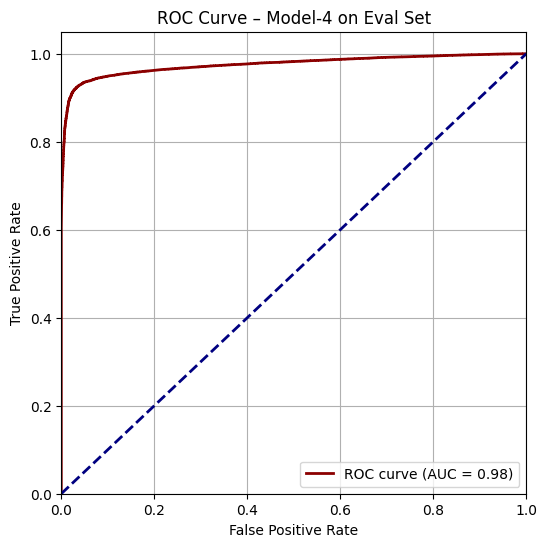


--- Starting Per-attack Evaluation on DEVELOPMENT Set ---
Starting DEVELOPMENT set per-attack score collection...


DEVELOPMENT Per-attack Evaluation: 100%|██████████| 24844/24844 [00:59<00:00, 417.68it/s]



--- Per-attack Performance on DEVELOPMENT Set ---
A01: EER=0.04%
A02: EER=0.04%
A03: EER=0.04%
A04: EER=0.04%
A05: EER=0.04%
A06: EER=0.04%
bonafide: EER=N/A (only bonafide samples found)
--------------------------------------------------

--- Starting Per-attack Evaluation on EVALUATION Set ---
Starting EVALUATION set per-attack score collection...


EVALUATION Per-attack Evaluation: 100%|██████████| 71237/71237 [02:48<00:00, 421.75it/s]



--- Per-attack Performance on EVALUATION Set ---
A11: EER=0.57%
A14: EER=0.15%
A16: EER=0.11%
A09: EER=0.03%
A13: EER=3.24%
A12: EER=7.17%
A18: EER=5.19%
A15: EER=0.46%
A08: EER=0.08%
A17: EER=32.45%
A10: EER=4.08%
A07: EER=0.03%
A19: EER=0.44%
bonafide: EER=N/A (only bonafide samples found)
--------------------------------------------------


In [14]:
# --- Load Model and Run Evaluations ---
# Load the single best checkpoint
try:
    checkpoint = torch.load(MODEL_CHECKPOINT)
    lcnn_model.load_state_dict(checkpoint['lcnn_state_dict'])
    cosface_layer.load_state_dict(checkpoint['cosface_state_dict'])
    print(f"Loaded best model from '{MODEL_CHECKPOINT}'.")
except FileNotFoundError:
    print(f"Error: Model checkpoint not found at '{MODEL_CHECKPOINT}'.")
    
    
# Evaluation for the Development set
dev_results = evaluate_model(
    lcnn_model, 
    cosface_layer, 
    dev_loader, 
    device, 
    dataset_name="Development Set"
)

# --- Evaluate and Plot for the Evaluation Set ---
eval_results = evaluate_model(
    lcnn_model, 
    cosface_layer, 
    eval_loader, 
    device, 
    dataset_name="Evaluation Set"
)

# Plot the results for the eval set
plot_roc_curve(eval_results, model_name="Model-4 on Eval Set")



# Per Attack-Type EERs
# Evaluate on the Development set
dev_eers = evaluate_per_attack(lcnn_model=lcnn_model, cosface_layer=cosface_layer,protocol_path=DEV_PROTOCOL,
                               output_dir=DEV_OUTPUT_DIR, device=device, dataset_name="DEVELOPMENT")

# Evaluate on the Evaluation set
eval_eers = evaluate_per_attack(lcnn_model=lcnn_model, cosface_layer=cosface_layer, protocol_path=EVAL_PROTOCOL, 
                                output_dir=EVAL_OUTPUT_DIR, device=device, dataset_name="EVALUATION")


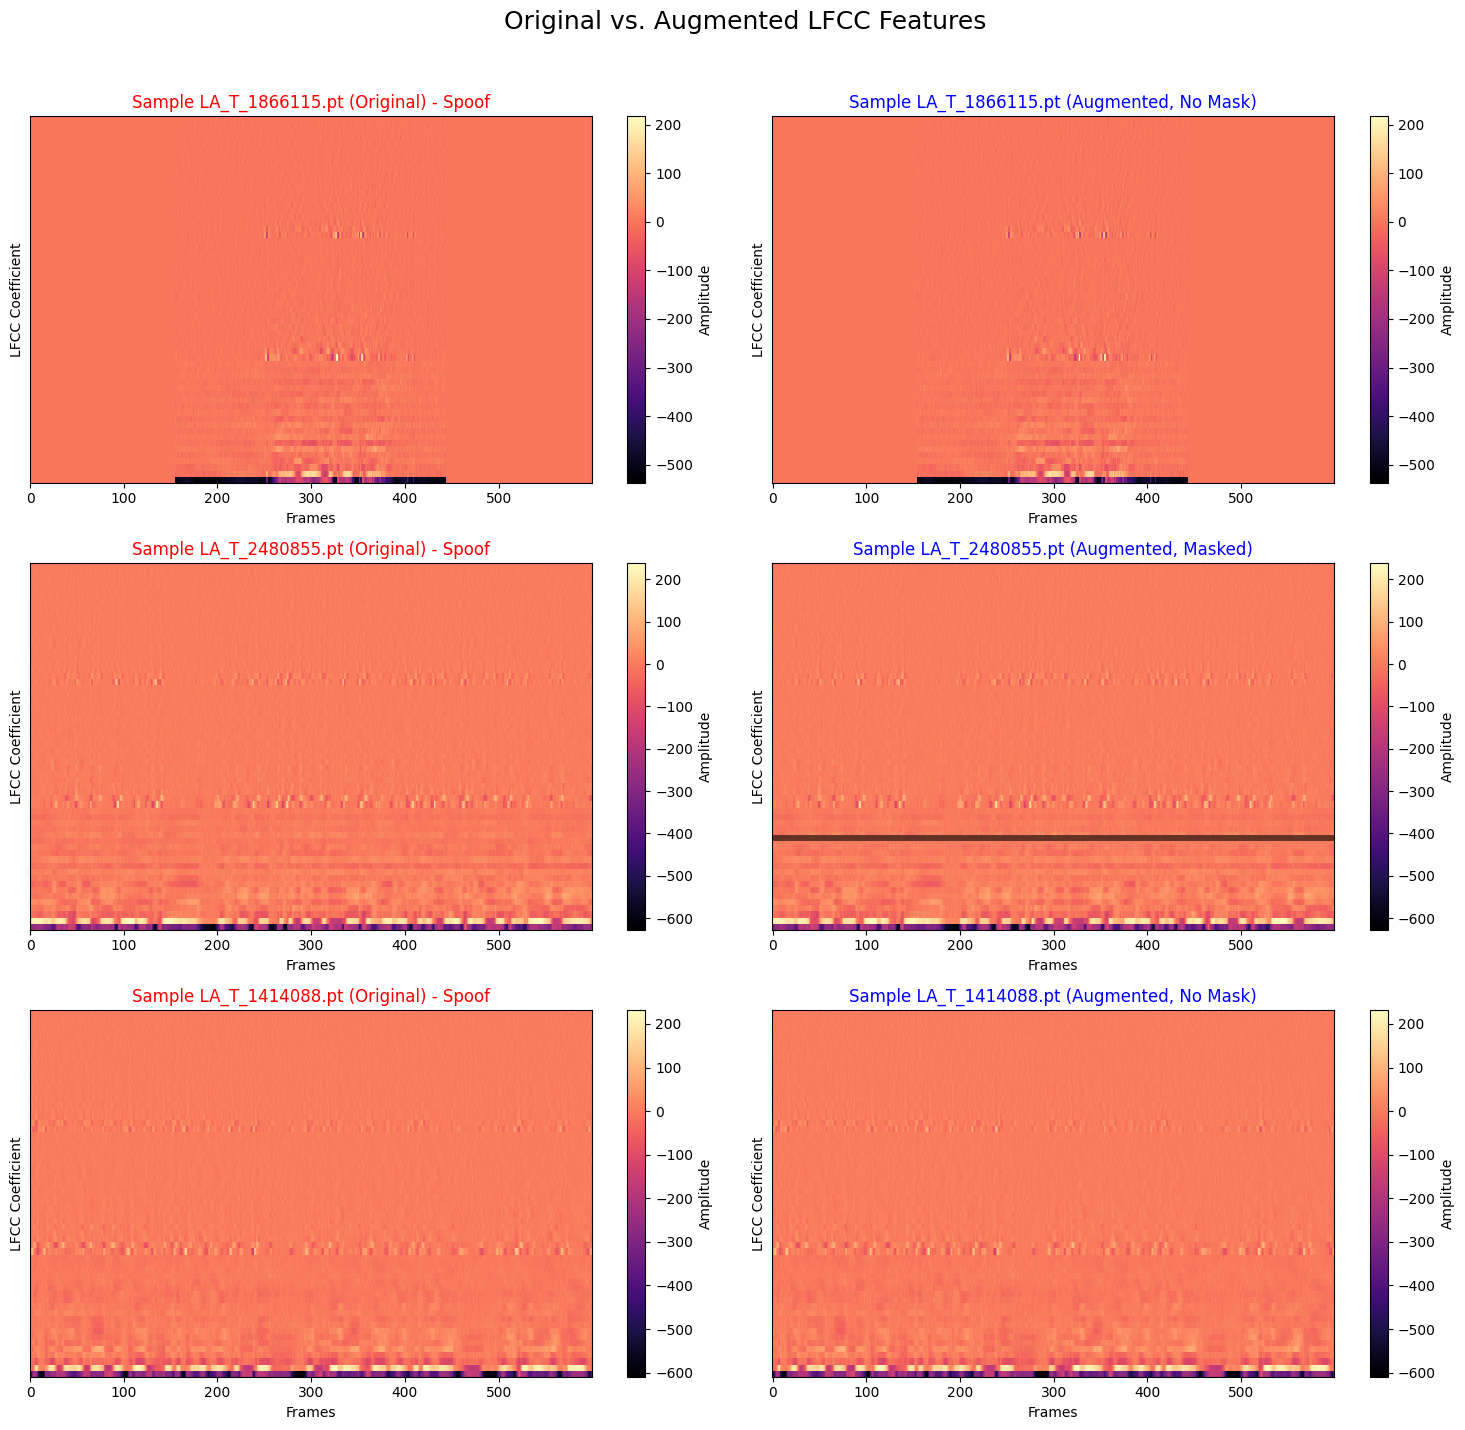

In [15]:
display_augmented_samples(TRAIN_OUTPUT_DIR)

# **Demonstration**

Using device: cuda
Successfully loaded model from '/kaggle/working/LFCC_LCNN_cosface_freqaug.pth'


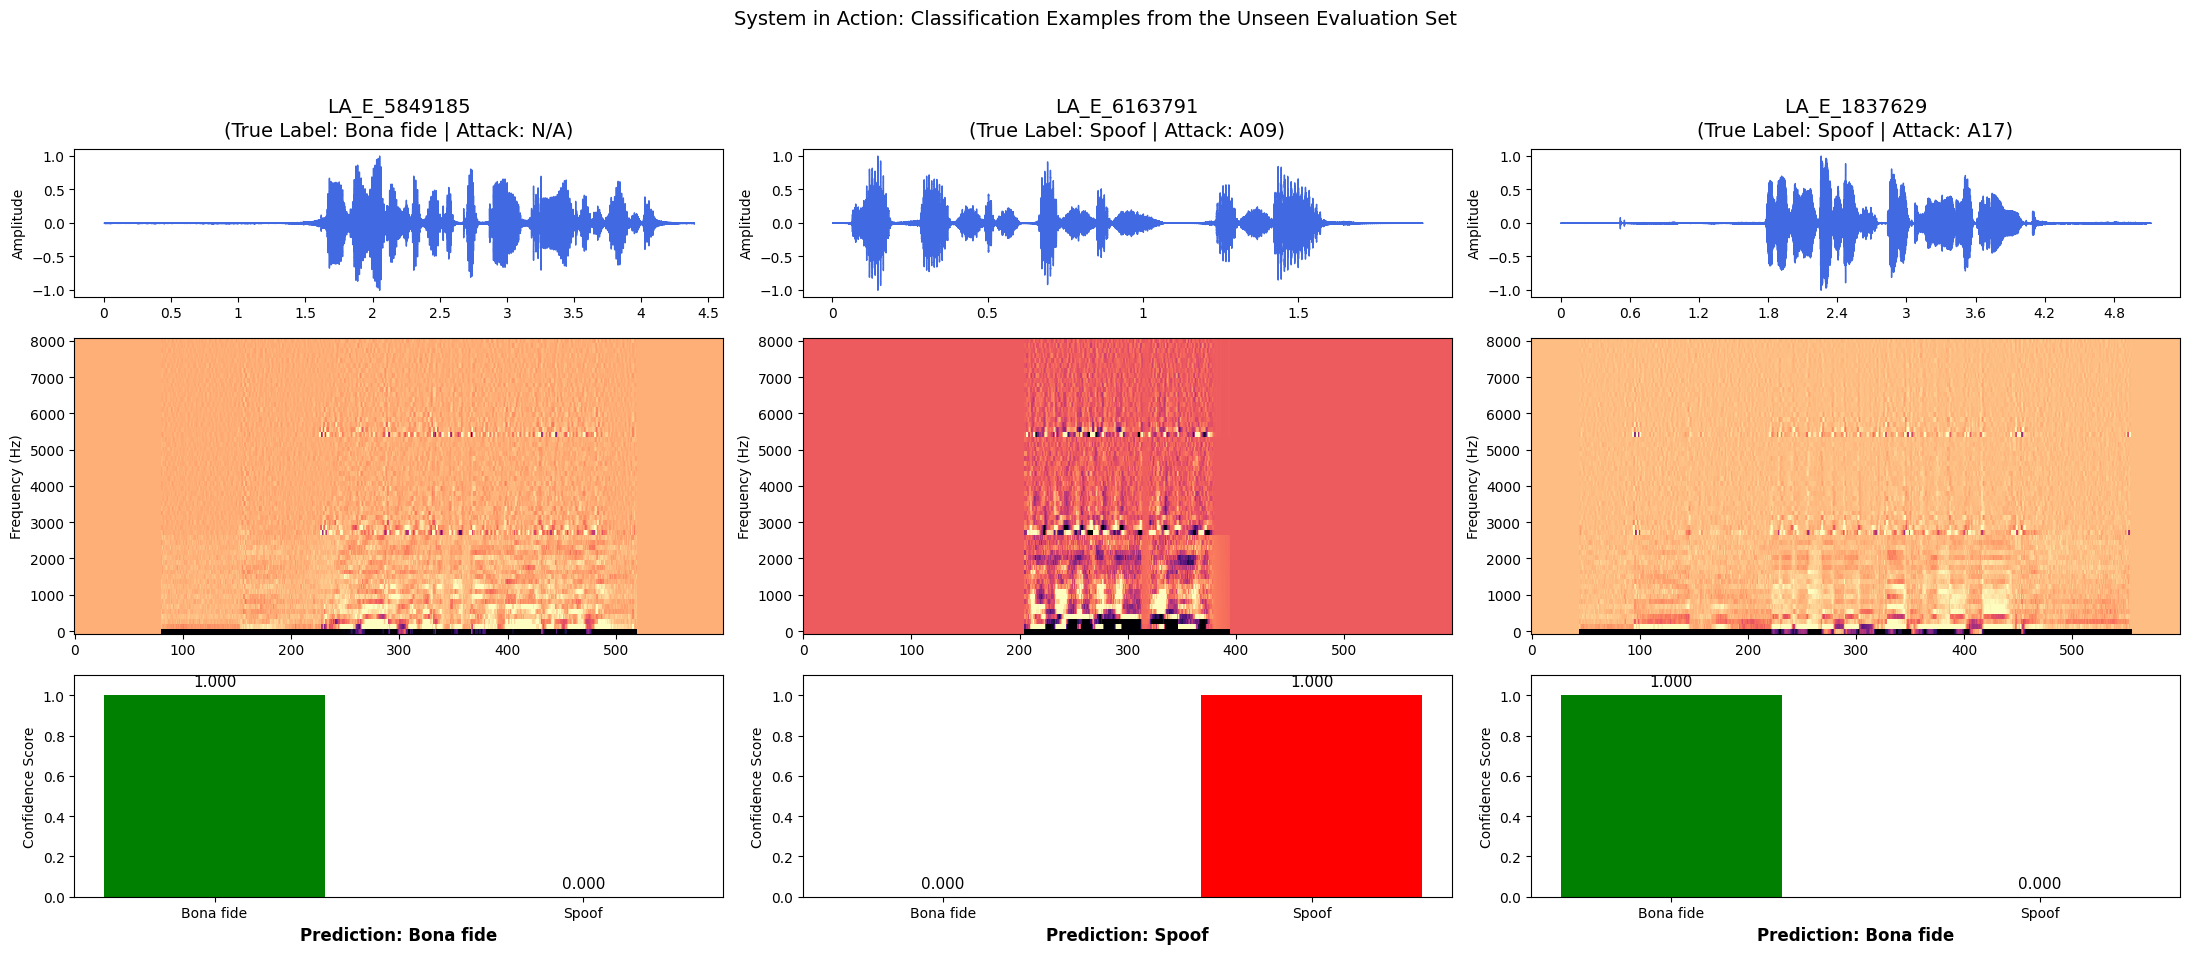

In [16]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

# --- Main Configuration (Adjust these paths as needed) ---
DATASET_BASE_DIR = '/kaggle/input/asvspoof-2019-la/ASVspoof2019_LA_wav'
PRECOMPUTED_BASE_DIR = '/kaggle/working/precomputed_lfcc'
MODEL_CHECKPOINT = '/kaggle/working/LFCC_LCNN_cosface_freqaug.pth'

EVAL_AUDIO_DIR = os.path.join(DATASET_BASE_DIR, 'ASVspoof2019_LA_eval', 'flac')
EVAL_OUTPUT_DIR = os.path.join(PRECOMPUTED_BASE_DIR, 'eval')

# --- Model Definitions (Copied from your notebook) ---
class MaxFeatureMap(nn.Module):
    def __init__(self):
        super(MaxFeatureMap, self).__init__()
    def forward(self, x):
        x1, x2 = torch.split(x, x.size(1) // 2, dim=1)
        return torch.max(x1, x2)

class LCNN(nn.Module):
    def __init__(self, sample_input_shape=(600, 60)):
        super(LCNN, self).__init__()
        self.mfm = MaxFeatureMap()
        self.conv1 = nn.Conv2d(1, 64, kernel_size=(5, 5), padding='same')
        self.mp1 = nn.MaxPool2d(kernel_size=(2, 2))
        self.conv4 = nn.Conv2d(32, 64, kernel_size=(1, 1), padding='same')
        self.bn1 = nn.BatchNorm2d(32)
        self.conv7 = nn.Conv2d(32, 96, kernel_size=(3, 3), padding='same')
        self.mp2 = nn.MaxPool2d(kernel_size=(2, 2))
        self.bn2 = nn.BatchNorm2d(48)
        self.conv11 = nn.Conv2d(48, 96, kernel_size=(1, 1), padding='same')
        self.bn3 = nn.BatchNorm2d(48)
        self.conv14 = nn.Conv2d(48, 128, kernel_size=(3, 3), padding='same')
        self.mp3 = nn.MaxPool2d(kernel_size=(2, 2))
        self.conv17 = nn.Conv2d(64, 128, kernel_size=(1, 1), padding='same')
        self.bn4 = nn.BatchNorm2d(64)
        self.conv20 = nn.Conv2d(64, 64, kernel_size=(3, 3), padding='same')
        self.bn5 = nn.BatchNorm2d(32)
        self.conv23 = nn.Conv2d(32, 64, kernel_size=(1, 1), padding='same')
        self.bn6 = nn.BatchNorm2d(32)
        self.conv26 = nn.Conv2d(32, 64, kernel_size=(3, 3), padding='same')
        self.mp4 = nn.MaxPool2d(kernel_size=(2, 2))
        dummy_input = torch.randn(1, 1, *sample_input_shape)
        conv_output = self._forward_conv(dummy_input)
        flattened_size = conv_output.reshape(1, -1).size(1)
        self.fc29 = nn.Linear(flattened_size, 160)
        self.bn7 = nn.BatchNorm1d(80)
        self.dropout = nn.Dropout(p=0.75)

    def _forward_conv(self, x):
        x = self.mfm(self.conv1(x)); x = self.mp1(x); x = self.mfm(self.conv4(x)); x = self.bn1(x)
        x = self.mfm(self.conv7(x)); x = self.mp2(x); x = self.bn2(x); x = self.mfm(self.conv11(x))
        x = self.bn3(x); x = self.mfm(self.conv14(x)); x = self.mp3(x); x = self.mfm(self.conv17(x))
        x = self.bn4(x); x = self.mfm(self.conv20(x)); x = self.bn5(x); x = self.mfm(self.conv23(x))
        x = self.bn6(x); x = self.mfm(self.conv26(x)); x = self.mp4(x)
        return x

    def forward(self, x):
        x = self._forward_conv(x); x = x.reshape(x.size(0), -1); x = self.fc29(x)
        x = x.view(x.size(0), 2, -1); x = torch.max(x, dim=1)[0]; x = self.bn7(x)
        embeddings = self.dropout(x)
        return embeddings

class CosFace(nn.Module):
    def __init__(self, in_features, num_classes, scale=10.0, margin=0.30):
        super(CosFace, self).__init__()
        self.in_features = in_features; self.num_classes = num_classes
        self.scale = scale; self.margin = margin
        self.W = nn.Parameter(torch.Tensor(in_features, num_classes))
        nn.init.xavier_uniform_(self.W)
    def forward(self, embeddings, labels=None):
        W_norm = F.normalize(self.W, p=2, dim=0)
        embeddings_norm = F.normalize(embeddings, p=2, dim=1)
        cosine_logits = embeddings_norm.mm(W_norm)
        if labels is None: return cosine_logits * self.scale
        one_hot = torch.zeros_like(cosine_logits)
        one_hot.scatter_(1, labels.view(-1, 1).long(), 1)
        target_logits = cosine_logits - self.margin
        output = (cosine_logits * (1 - one_hot)) + (target_logits * one_hot)
        output *= self.scale
        return output

def plot_sample_in_subplot(lcnn_model, cosface_layer, file_id, attack_type, true_label, device, axs, col_idx):
    """Loads a sample, performs inference, and plots results in a specified subplot column."""
    audio_path = os.path.join(EVAL_AUDIO_DIR, file_id + '.wav')
    feature_path = os.path.join(EVAL_OUTPUT_DIR, file_id + '.pt')

    if not os.path.exists(audio_path) or not os.path.exists(feature_path):
        print(f"Files for {file_id} not found. Skipping.")
        return

    # --- Define axes for this column ---
    ax_wav, ax_spec, ax_bar = axs[0, col_idx], axs[1, col_idx], axs[2, col_idx]
    
    # --- Load Data ---
    waveform, sr = torchaudio.load(audio_path)
    data = torch.load(feature_path)
    features_tensor = data['features'].float() # Shape [600, 60, 1]

    # --- Perform Inference ---
    lcnn_model.eval()
    cosface_layer.eval()
    with torch.no_grad():
        features_for_model = features_tensor.unsqueeze(0).permute(0, 3, 1, 2).to(device)
        embeddings = lcnn_model(features_for_model)
        logits = cosface_layer(embeddings, labels=None)
        scores = F.softmax(logits, dim=1).squeeze().cpu().numpy()
        prediction_idx = np.argmax(scores)
        prediction_label = "Bona fide" if prediction_idx == 0 else "Spoof"

    # --- Plotting ---
    # Column Title
    ax_wav.set_title(f'{file_id}\n(True Label: {true_label} | Attack: {attack_type})', fontsize=14, pad=10)

    # 1. Waveform Plot
    librosa.display.waveshow(waveform.numpy().flatten(), sr=sr, ax=ax_wav, color='royalblue')
    ax_wav.set_xlabel('')
    ax_wav.set_ylabel('Amplitude')

    # 2. LFCC Spectrogram Plot
    lfcc_display = features_tensor.squeeze().cpu().numpy().T
    vmin, vmax = np.percentile(lfcc_display, 1), np.percentile(lfcc_display, 99)
    img = librosa.display.specshow(lfcc_display, cmap = 'magma', x_axis='frames', y_axis='hz', sr=sr, ax=ax_spec, vmin =vmin, vmax= vmax)
    ax_spec.set_ylabel('Frequency (Hz)')
    ax_spec.set_xlabel('')

    # 3. Bar Chart of Scores
    bar_colors = ['green', 'red'] if prediction_label == true_label else ['red', 'green']
    if prediction_idx == 0:
        bar_colors = ['green', 'grey']
    else:
        bar_colors = ['grey', 'red']
        
    bars = ax_bar.bar(['Bona fide', 'Spoof'], scores, color=bar_colors, width=0.6)
    ax_bar.set_ylabel('Confidence Score')
    ax_bar.set_xlabel(f'Prediction: {prediction_label}', fontsize=12, weight='bold')
    ax_bar.set_ylim(0, 1.1)
    for bar in bars:
        yval = bar.get_height()
        ax_bar.text(bar.get_x() + bar.get_width()/2.0, yval + 0.03, f'{yval:.3f}', ha='center', va='bottom', fontsize=11)

# --- Main Execution Block ---
if __name__ == "__main__":
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    try:
        lcnn = LCNN().to(device)
        cosface = CosFace(in_features=80, num_classes=2).to(device)
        
        checkpoint = torch.load(MODEL_CHECKPOINT, map_location=device)
        lcnn.load_state_dict(checkpoint['lcnn_state_dict'])
        cosface.load_state_dict(checkpoint['cosface_state_dict'])
        print(f"Successfully loaded model from '{MODEL_CHECKPOINT}'")

        # --- Define Samples to Process ---
        samples_to_plot = [
            {'id': 'LA_E_5849185', 'attack': 'N/A', 'label': 'Bona fide'},
            {'id': 'LA_E_6163791', 'attack': 'A09', 'label': 'Spoof'},
            {'id': 'LA_E_1837629', 'attack': 'A17', 'label': 'Spoof'}
        ]

        # --- Create a single figure with 1x3 subplots ---
        fig, axs = plt.subplots(3, 3, figsize=(22, 10), gridspec_kw={'height_ratios': [1, 2, 1.5]})
        fig.suptitle('System in Action: Classification Examples from the Unseen Evaluation Set', fontsize=14)
        
        # --- Generate a plot for each sample in its respective column ---
        for i, sample in enumerate(samples_to_plot):
            plot_sample_in_subplot(
                lcnn, cosface, 
                sample['id'], sample['attack'], sample['label'], 
                device, axs, i
            )
        
        # --- Final adjustments and display ---
        plt.tight_layout(rect=[0, 0.03, 1, 0.94])
        plt.show()

    except FileNotFoundError:
        print(f"ERROR: Model checkpoint '{MODEL_CHECKPOINT}' not found.")
    except Exception as e:
        print(f"An error occurred: {e}")